# Notebook 06: Final Evaluation

This notebook is the final artifact-only analysis of the single sealed test evaluation for the frozen S8-CFD baseline model. It reads committed artifacts from the frozen baseline experiment and the final test-evaluation report only. It does not train, run inference, access W&B, load checkpoints, retune thresholds, invoke dataset loaders, or access the test split outside the committed final artifacts.


## 1. Final Evaluation Protocol

The final evaluation uses the frozen S8-CFD baseline validation-best checkpoint from epoch 19. The model was selected by validation `mAP50-95`, and the operating threshold `0.999` was selected entirely on validation before sealed test evaluation.

Protocol constants:

```text
Final model:       S8-CFD baseline
Checkpoint:        validation-best checkpoint, epoch 19
Selection metric:  validation mAP50-95
Threshold:         0.999, selected entirely on validation
Eval floor:        0.001
NMS IoU:           0.50
EVAL_TOP_K:        500
MAX_DETECTIONS:    100
```


## 2. Explicit Frozen-Before-Test Statement

Before any sealed test results were examined, the final model, checkpoint, validation-selected operating threshold, evaluation floor, NMS setting, top-k limit, and maximum detections were already fixed. The IoU-loss ablation was not selected because it did not improve the predetermined validation `mAP50-95`.

The sealed test evaluation is used exactly once here as the final held-out estimate. There is no test threshold tuning, no threshold sweep, no IoU-model test evaluation, and no model reselection after test results.


In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

BASELINE_DIR = PROJECT_ROOT / "reports" / "experiments" / "baseline-s8-cfd-960-s8"
FINAL_DIR = PROJECT_ROOT / "reports" / "final" / "s8-cfd-test"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_ARTIFACTS = {
    "baseline_config": BASELINE_DIR / "config.json",
    "baseline_best_checkpoint": BASELINE_DIR / "metrics" / "best_checkpoint.json",
    "baseline_val_metrics": BASELINE_DIR / "metrics" / "val_inference_metrics.json",
    "final_config": FINAL_DIR / "config.json",
    "test_metrics": FINAL_DIR / "metrics" / "test_inference_metrics.json",
    "test_qualitative_examples": FINAL_DIR / "qualitative" / "examples",
}
missing = {name: path for name, path in REQUIRED_ARTIFACTS.items() if not path.exists()}
if missing:
    raise FileNotFoundError("Missing required final-evaluation artifacts: " + ", ".join(f"{name}={path}" for name, path in missing.items()))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

def save_figure(fig: plt.Figure, name: str) -> None:
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {png_path.relative_to(PROJECT_ROOT)} and {pdf_path.relative_to(PROJECT_ROOT)}")

baseline_config = load_json(REQUIRED_ARTIFACTS["baseline_config"])
baseline_best_checkpoint = load_json(REQUIRED_ARTIFACTS["baseline_best_checkpoint"])
val_metrics = load_json(REQUIRED_ARTIFACTS["baseline_val_metrics"])
final_config = load_json(REQUIRED_ARTIFACTS["final_config"])
test_metrics = load_json(REQUIRED_ARTIFACTS["test_metrics"])
qualitative_paths = sorted(REQUIRED_ARTIFACTS["test_qualitative_examples"].glob("*.png"))

artifact_inventory = []
for root in [BASELINE_DIR, FINAL_DIR]:
    for path in sorted(root.rglob("*")):
        if path.is_file():
            artifact_inventory.append({
                "root": str(root.relative_to(PROJECT_ROOT)),
                "relative_path": str(path.relative_to(PROJECT_ROOT)),
                "size_kib": path.stat().st_size / 1024,
            })
artifact_df = pd.DataFrame(artifact_inventory)
display(artifact_df)
print(f"Loaded {len(qualitative_paths)} committed representative test examples.")


,root,relative_path,size_kib
0,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/con...,2.161133
1,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/met...,0.160156
2,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/met...,5.781250
3,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/met...,1.409180
4,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/qua...,1132.060547
5,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/qua...,1183.985352
6,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/qua...,1429.055664
7,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/qua...,1558.584961
8,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/qua...,865.523438
9,reports/experiments/baseline-s8-cfd-960-s8,reports/experiments/baseline-s8-cfd-960-s8/qua...,942.643555


Loaded 12 committed representative test examples.


## 3. Final Model Configuration

The configuration table records the frozen model and evaluation settings from the committed artifacts. The test split appears only through `reports/final/s8-cfd-test/` artifacts.


In [2]:
assert baseline_config["run_name"] == "baseline-s8-cfd-960-s8"
assert baseline_best_checkpoint["metric_name"] == "val_map50_95"
assert int(baseline_best_checkpoint["best_epoch"]) == 19
assert int(val_metrics["checkpoint_epoch"]) == 19
assert int(test_metrics["checkpoint_epoch"]) == 19
assert val_metrics["split"] == "val"
assert test_metrics["split"] == "test"
assert str(val_metrics["checkpoint"]).replace("\\", "/").endswith("baseline-s8-cfd-960-s8/best.pt")
assert str(test_metrics["checkpoint"]).replace("\\", "/").endswith("baseline-s8-cfd-960-s8/best.pt")

for metrics in [val_metrics, test_metrics]:
    assert math.isclose(float(metrics["operating_confidence_threshold"]), 0.999, rel_tol=0, abs_tol=1e-12)
    assert math.isclose(float(metrics["eval_confidence_floor"]), 0.001, rel_tol=0, abs_tol=1e-12)
    assert math.isclose(float(metrics["nms_iou_threshold"]), 0.50, rel_tol=0, abs_tol=1e-12)
    assert int(metrics["eval_top_k"]) == 500
    assert int(metrics["max_detections"]) == 100

detector = baseline_config["detector_config"]
config_table = pd.DataFrame([
    {"setting": "final model", "value": "S8-CFD baseline"},
    {"setting": "checkpoint", "value": val_metrics["checkpoint"]},
    {"setting": "checkpoint epoch", "value": int(val_metrics["checkpoint_epoch"])},
    {"setting": "selection metric", "value": baseline_best_checkpoint["metric_name"]},
    {"setting": "input resolution", "value": f'{detector["input_width"]}x{detector["input_height"]}'},
    {"setting": "stride", "value": detector["stride"]},
    {"setting": "loss", "value": "L_obj + 5 L_center + 2 L_size"},
    {"setting": "validation-selected threshold", "value": val_metrics["operating_confidence_threshold"]},
    {"setting": "eval floor", "value": test_metrics["eval_confidence_floor"]},
    {"setting": "NMS IoU", "value": test_metrics["nms_iou_threshold"]},
    {"setting": "EVAL_TOP_K", "value": test_metrics["eval_top_k"]},
    {"setting": "MAX_DETECTIONS", "value": test_metrics["max_detections"]},
])
display(config_table)


,setting,value
0,final model,S8-CFD baseline
1,checkpoint,models\checkpoints\baseline-s8-cfd-960-s8\best.pt
2,checkpoint epoch,19
3,selection metric,val_map50_95
4,input resolution,960x544
5,stride,8
6,loss,L_obj + 5 L_center + 2 L_size
7,validation-selected threshold,0.999
8,eval floor,0.001
9,NMS IoU,0.5


## 4. Validation vs Sealed-Test Comparison Table

The table below computes validation-to-test absolute differences directly from committed artifacts. Differences are `test - validation`, so negative values indicate a decrease on sealed test.


In [3]:
def metrics_row(name: str, metrics: dict) -> dict[str, float | int | str]:
    return {
        "split": name,
        "images": int(metrics["image_count"]),
        "objects": int(float(metrics["true_positives"]) + float(metrics["false_negatives"])),
        "AP50": float(metrics["ap50"]),
        "AP75": float(metrics["ap75"]),
        "mAP50-95": float(metrics["map50_95"]),
        "Precision": float(metrics["precision"]),
        "Recall": float(metrics["recall"]),
        "F1": float(metrics["f1"]),
        "threshold": float(metrics["operating_confidence_threshold"]),
    }

comparison_df = pd.DataFrame([metrics_row("validation", val_metrics), metrics_row("sealed test", test_metrics)])
metric_cols = ["AP50", "AP75", "mAP50-95", "Precision", "Recall", "F1"]
delta_row = {"split": "test - validation", "images": np.nan, "objects": np.nan, "threshold": np.nan}
for col in metric_cols:
    delta_row[col] = float(comparison_df.loc[comparison_df["split"] == "sealed test", col].iloc[0] - comparison_df.loc[comparison_df["split"] == "validation", col].iloc[0])
comparison_with_delta = pd.concat([comparison_df, pd.DataFrame([delta_row])], ignore_index=True)
display(comparison_with_delta)

expected = {
    "validation": {
        "AP50": 0.9375629425,
        "AP75": 0.4037680626,
        "mAP50-95": 0.4791892208,
        "Precision": 0.9611231102,
        "Recall": 0.9081632653,
        "F1": 0.9338929696,
    },
    "sealed test": {
        "images": 459,
        "objects": 918,
        "AP50": 0.8811097741,
        "AP75": 0.3026017249,
        "mAP50-95": 0.4115266151,
        "Precision": 0.9437125749,
        "Recall": 0.8583877996,
        "F1": 0.8990302339,
        "threshold": 0.999,
    },
}
for split, refs in expected.items():
    row = comparison_df.loc[comparison_df["split"] == split].iloc[0]
    for key, value in refs.items():
        atol = 5e-10 if key not in {"images", "objects"} else 0
        assert math.isclose(float(row[key]), float(value), rel_tol=0, abs_tol=atol), (split, key, row[key], value)

delta_checks = {
    "AP50": -0.05645,
    "AP75": -0.10117,
    "mAP50-95": -0.06766,
    "Precision": -0.01741,
    "Recall": -0.04978,
    "F1": -0.03486,
}
for key, value in delta_checks.items():
    actual = float(delta_row[key])
    assert math.isclose(actual, value, rel_tol=0, abs_tol=5e-5), (key, actual, value)


,split,images,objects,AP50,AP75,mAP50-95,Precision,Recall,F1,threshold
0,validation,245.0,490.0,0.937563,0.403768,0.479189,0.961123,0.908163,0.933893,0.999
1,sealed test,459.0,918.0,0.881110,0.302602,0.411527,0.943713,0.858388,0.899030,0.999
2,test - validation,NaN,NaN,-0.056453,-0.101166,-0.067663,-0.017411,-0.049775,-0.034863,NaN


## 5. Validation vs Test AP50/AP75/mAP Figure

Ranked AP decreases on the sealed test set relative to validation. AP75 shows the largest AP reduction among the plotted AP metrics.


Saved reports/figures/final_evaluation_ap_comparison.png and reports/figures/final_evaluation_ap_comparison.pdf


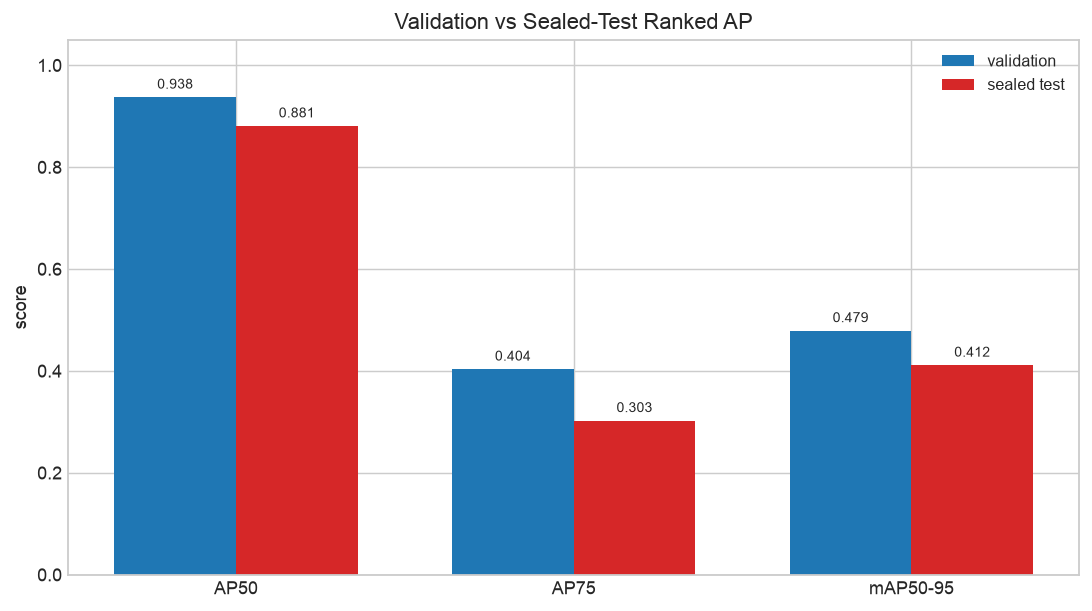

In [4]:
plot_metric_df = comparison_df[comparison_df["split"].isin(["validation", "sealed test"])]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(3)
width = 0.36
for offset, split, color in [(-width / 2, "validation", "#1f77b4"), (width / 2, "sealed test", "#d62728")]:
    values = [float(plot_metric_df.loc[plot_metric_df["split"] == split, col].iloc[0]) for col in ["AP50", "AP75", "mAP50-95"]]
    bars = ax.bar(x + offset, values, width=width, label=split, color=color)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(["AP50", "AP75", "mAP50-95"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Validation vs Sealed-Test Ranked AP")
ax.legend()
fig.tight_layout()
save_figure(fig, "final_evaluation_ap_comparison")
plt.show()


## 6. Validation vs Test Precision/Recall/F1 Figure

Operating precision, recall, and F1 are evaluated at the frozen validation-selected threshold `0.999`. No test threshold tuning is performed.


Saved reports/figures/final_evaluation_operating_metrics.png and reports/figures/final_evaluation_operating_metrics.pdf


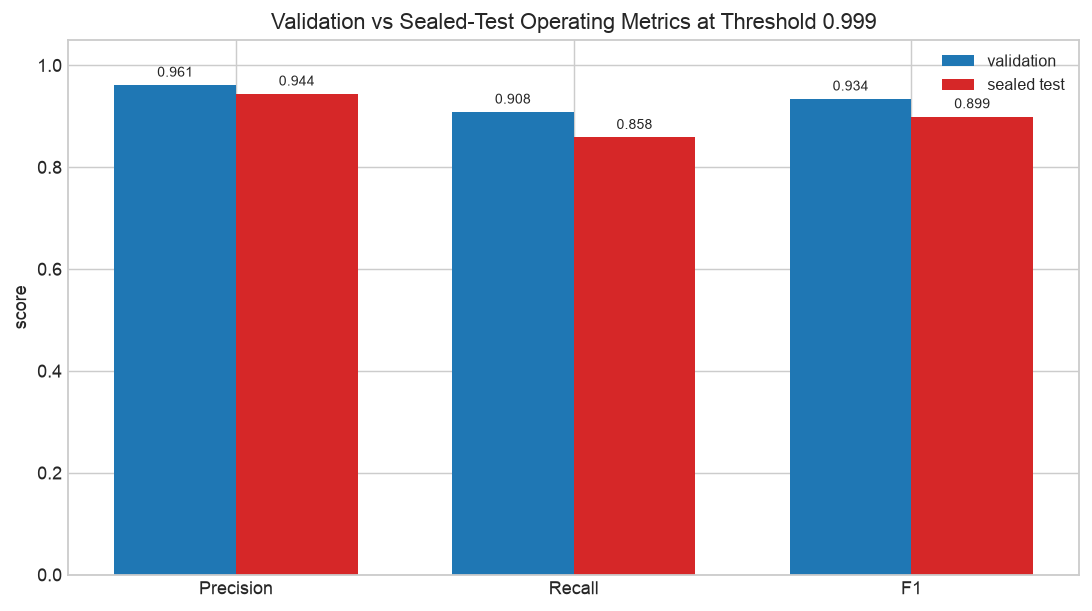

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(3)
width = 0.36
for offset, split, color in [(-width / 2, "validation", "#1f77b4"), (width / 2, "sealed test", "#d62728")]:
    values = [float(plot_metric_df.loc[plot_metric_df["split"] == split, col].iloc[0]) for col in ["Precision", "Recall", "F1"]]
    bars = ax.bar(x + offset, values, width=width, label=split, color=color)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Validation vs Sealed-Test Operating Metrics at Threshold 0.999")
ax.legend()
fig.tight_layout()
save_figure(fig, "final_evaluation_operating_metrics")
plt.show()


## 7. TP/FP/FN and Predictions-Per-Image Summary

The sealed test run produced 835 displayed predictions at the frozen threshold, or about 1.82 predictions per image.

Validation and sealed test have different sample/object counts, so raw TP/FP/FN totals are descriptive and should not be compared as normalized rates. Precision, recall, and F1 are the comparable operating-rate metrics.


,split,images,objects,TP,FP,FN,predictions,predictions_per_image
0,validation,245,490,445,18,45,463,1.889796
1,sealed test,459,918,788,47,130,835,1.819172


Saved reports/figures/final_evaluation_operating_counts.png and reports/figures/final_evaluation_operating_counts.pdf


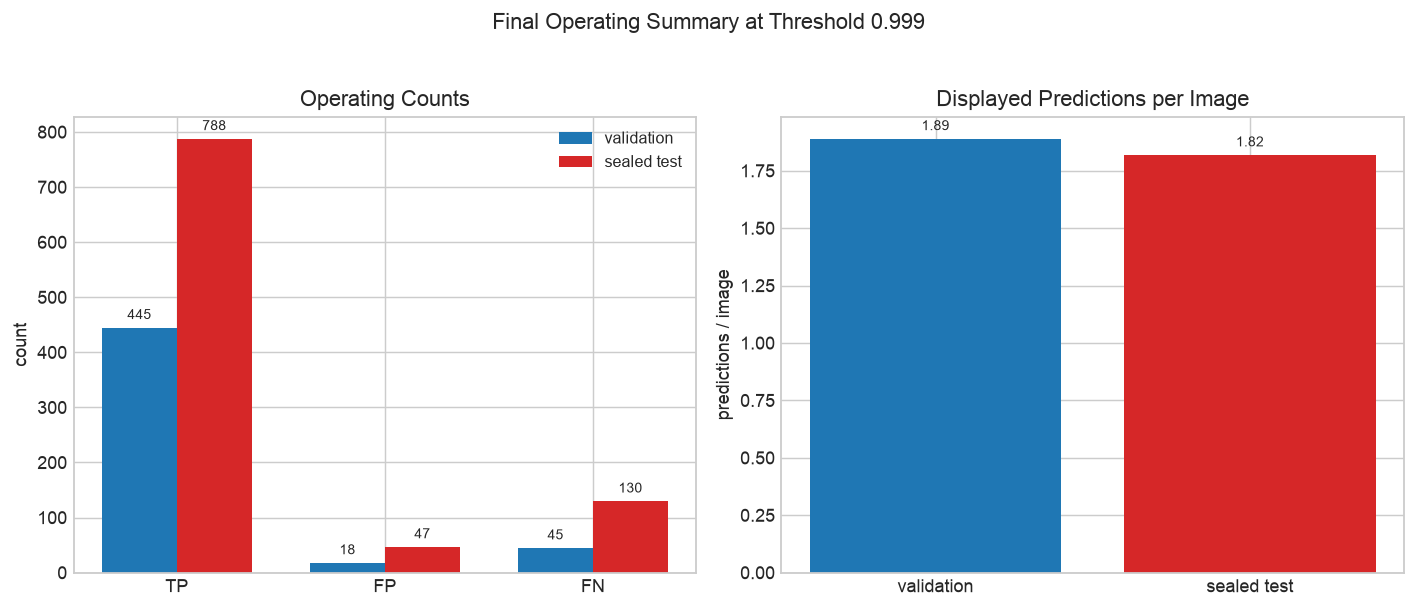

In [6]:
count_rows = []
for split, metrics in [("validation", val_metrics), ("sealed test", test_metrics)]:
    count_rows.append({
        "split": split,
        "images": int(metrics["image_count"]),
        "objects": int(float(metrics["true_positives"]) + float(metrics["false_negatives"])),
        "TP": int(float(metrics["true_positives"])),
        "FP": int(float(metrics["false_positives"])),
        "FN": int(float(metrics["false_negatives"])),
        "predictions": int(metrics["display_predictions"]),
        "predictions_per_image": float(metrics["display_predictions_per_image"]),
    })
count_df = pd.DataFrame(count_rows)
display(count_df)

assert int(count_df.loc[count_df["split"] == "sealed test", "TP"].iloc[0]) == 788
assert int(count_df.loc[count_df["split"] == "sealed test", "FP"].iloc[0]) == 47
assert int(count_df.loc[count_df["split"] == "sealed test", "FN"].iloc[0]) == 130
assert int(count_df.loc[count_df["split"] == "sealed test", "predictions"].iloc[0]) == 835
assert math.isclose(float(count_df.loc[count_df["split"] == "sealed test", "predictions_per_image"].iloc[0]), 1.8191721133, rel_tol=0, abs_tol=5e-10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
count_metric_df = count_df.melt(id_vars="split", value_vars=["TP", "FP", "FN"], var_name="count_type", value_name="count")
positions = np.arange(3)
width = 0.36
for offset, split, color in [(-width / 2, "validation", "#1f77b4"), (width / 2, "sealed test", "#d62728")]:
    values = [int(count_metric_df[(count_metric_df["split"] == split) & (count_metric_df["count_type"] == c)]["count"].iloc[0]) for c in ["TP", "FP", "FN"]]
    bars = axes[0].bar(positions + offset, values, width=width, label=split, color=color)
    axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(["TP", "FP", "FN"])
axes[0].set_ylabel("count")
axes[0].set_title("Operating Counts")

bars = axes[1].bar(count_df["split"], count_df["predictions_per_image"], color=["#1f77b4", "#d62728"])
axes[1].bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
axes[1].set_ylabel("predictions / image")
axes[1].set_title("Displayed Predictions per Image")
for ax in axes:
    ax.legend() if ax is axes[0] else None
fig.suptitle("Final Operating Summary at Threshold 0.999", y=1.03)
fig.tight_layout()
save_figure(fig, "final_evaluation_operating_counts")
plt.show()


## 8. Score-Distribution Summary from Saved Metrics

The score summaries below are copied from the saved post-NMS score distributions after the evaluation confidence floor. They are descriptive only and are not used for threshold tuning.


,split,min,p25,median,p75,max,mean
0,validation,0.001001,0.015159,0.103293,0.546144,0.999999,0.292811
1,sealed test,0.001000,0.018354,0.125220,0.579383,1.000000,0.304986


Saved reports/figures/final_evaluation_score_distribution.png and reports/figures/final_evaluation_score_distribution.pdf


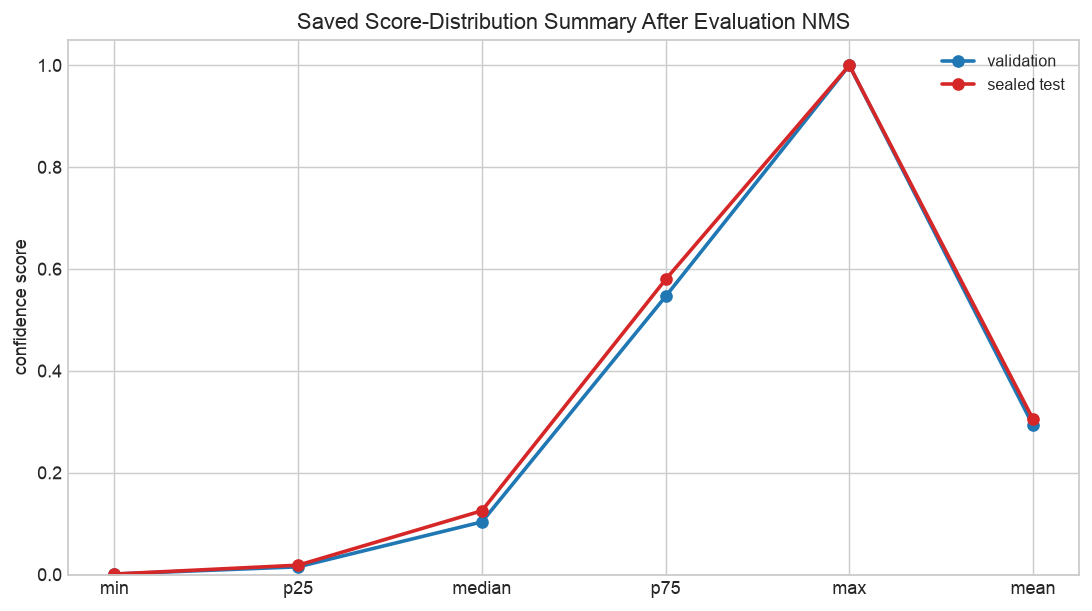

In [7]:
score_rows = []
for split, metrics in [("validation", val_metrics), ("sealed test", test_metrics)]:
    dist = metrics["score_distribution_after_eval_nms"]
    row = {"split": split}
    for key in ["min", "p25", "median", "p75", "max", "mean"]:
        row[key] = float(dist[key])
    score_rows.append(row)
score_df = pd.DataFrame(score_rows)
display(score_df)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
quantiles = ["min", "p25", "median", "p75", "max", "mean"]
x = np.arange(len(quantiles))
for split, color in [("validation", "#1f77b4"), ("sealed test", "#d62728")]:
    values = [float(score_df.loc[score_df["split"] == split, q].iloc[0]) for q in quantiles]
    ax.plot(x, values, marker="o", linewidth=2, label=split, color=color)
ax.set_xticks(x)
ax.set_xticklabels(quantiles)
ax.set_ylim(0, 1.05)
ax.set_ylabel("confidence score")
ax.set_title("Saved Score-Distribution Summary After Evaluation NMS")
ax.legend()
fig.tight_layout()
save_figure(fig, "final_evaluation_score_distribution")
plt.show()


## 9. Representative Qualitative Test Examples

The panel uses only the committed representative examples under `reports/final/s8-cfd-test/qualitative/examples/`. No additional test images are selected or generated here.

The committed 12-image subset was curated for coverage across raw/augmented, city/forest/lake, and sunny/foggy conditions, not selected based on prediction correctness or confidence.


,file,raw_or_augmented,scene,weather
0,0021_augmented_raw_dataset_city_foggy_city_fog...,augmented,city,foggy
1,0036_augmented_raw_dataset_city_sunny_city_sun...,augmented,city,sunny
2,0101_augmented_raw_dataset_forest_foggy_forest...,augmented,forest,foggy
3,0118_augmented_raw_dataset_forest_sunny_forest...,augmented,forest,sunny
4,0183_augmented_raw_dataset_lake_foggy_lake_fog...,augmented,lake,foggy
5,0195_augmented_raw_dataset_lake_sunny_lake_sun...,augmented,lake,sunny
6,0234_raw_dataset_city_foggy_city_foggy_12_13_s...,raw,city,foggy
7,0294_raw_dataset_city_sunny_city_sunny_2_3_seq...,raw,city,sunny
8,0314_raw_dataset_forest_foggy_forest_foggy_12_...,raw,forest,foggy
9,0367_raw_dataset_forest_sunny_forest_sunny_2_3...,raw,forest,sunny


Saved reports/figures/final_evaluation_qualitative_examples.png and reports/figures/final_evaluation_qualitative_examples.pdf


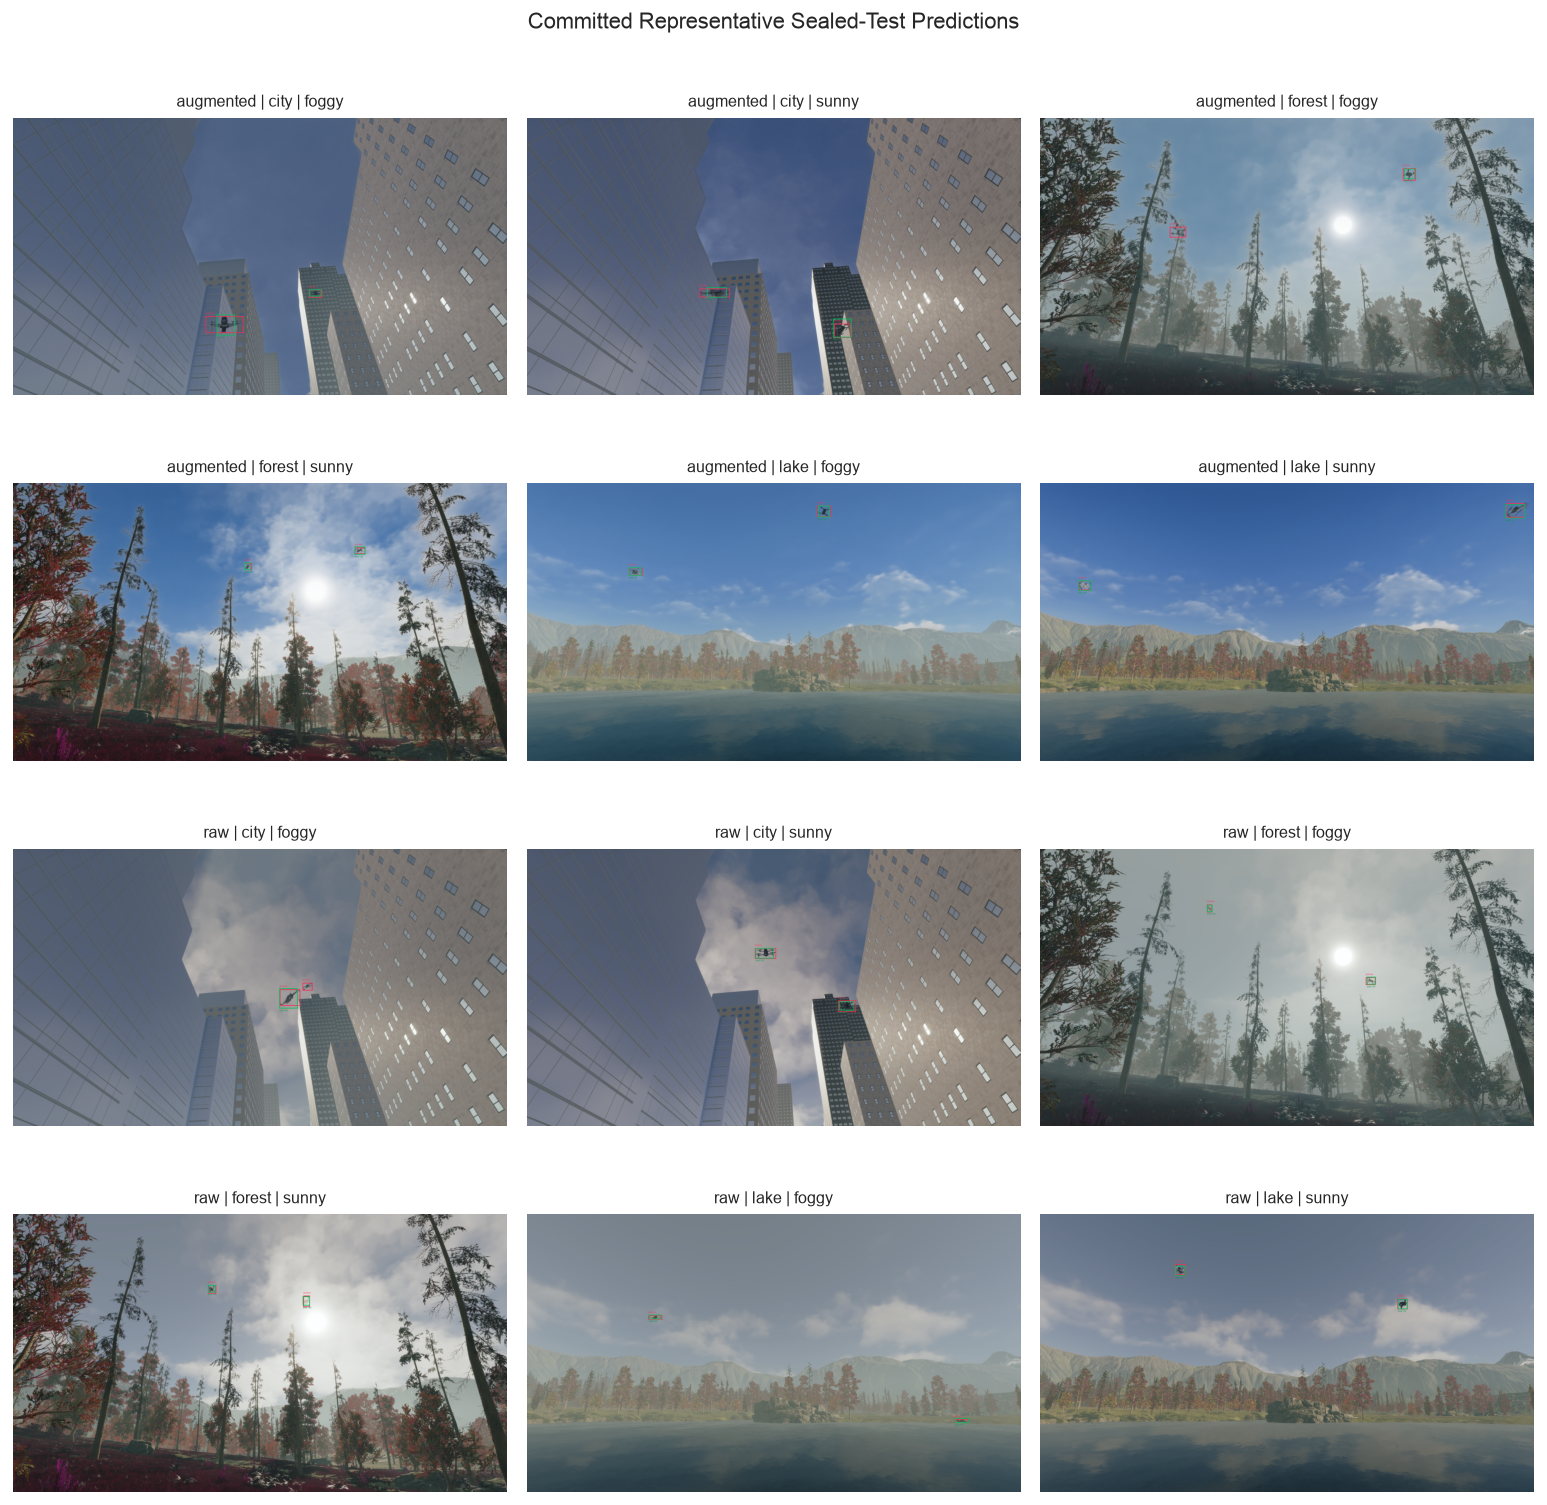

In [8]:
def parse_example_name(path: Path) -> dict[str, str]:
    name = path.name
    encoded_name = re.sub(r"^\d+_", "", path.stem)
    if encoded_name.startswith("augmented_"):
        raw_or_augmented = "augmented"
    elif encoded_name.startswith("raw_"):
        raw_or_augmented = "raw"
    else:
        raw_or_augmented = "unknown"
    scene = next((candidate for candidate in ["city", "forest", "lake"] if f"_{candidate}_" in name), "unknown")
    weather = next((candidate for candidate in ["sunny", "foggy"] if f"_{candidate}_" in name), "unknown")
    return {"file": name, "raw_or_augmented": raw_or_augmented, "scene": scene, "weather": weather}

example_meta = pd.DataFrame([parse_example_name(path) for path in qualitative_paths])
display(example_meta)
assert len(example_meta) == 12
assert set(example_meta["raw_or_augmented"]) == {"raw", "augmented"}

cols = 3
rows = math.ceil(len(qualitative_paths) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(12, 3.0 * rows))
axes = np.array(axes).reshape(-1)
for ax, path in zip(axes, qualitative_paths):
    with Image.open(path) as image:
        ax.imshow(image)
    meta = parse_example_name(path)
    ax.set_title(f"{meta['raw_or_augmented']} | {meta['scene']} | {meta['weather']}", fontsize=9)
    ax.axis("off")
for ax in axes[len(qualitative_paths):]:
    ax.axis("off")
fig.suptitle("Committed Representative Sealed-Test Predictions", y=0.995)
fig.tight_layout()
save_figure(fig, "final_evaluation_qualitative_examples")
plt.show()


## 10. Generalization-Gap Discussion

The sealed test results remain strong and useful, especially at AP50-level detection and at the frozen operating threshold. Performance decreases relative to validation across AP and operating metrics. The largest AP reduction is AP75, which indicates that strict localization generalizes less strongly than AP50-level detection.

Held-out capture-pair conditions may contribute to the validation-to-test gap, but this notebook does not establish causality. The results should not be labeled definite overfitting without stronger evidence such as repeated seeds, additional controlled splits, or deeper error analysis.


## 11. Final Conclusions and Limitations

The final selected model remains the frozen S8-CFD baseline validation-best checkpoint from epoch 19. The sealed test estimate is lower than validation but still operationally meaningful: AP50 is high, the frozen threshold retains high precision, and recall remains substantial. The AP75 drop is the clearest weakness and is consistent with localization being harder to generalize than coarse detection.

Limitations: this notebook analyzes one final test evaluation, uses only committed artifacts, and does not retune any test-time decisions. It does not evaluate the IoU ablation on the sealed test set, does not reselect models after seeing test results, and does not treat the sealed test split as another validation set.
